# Exploring GAN Variants for Balancing Imbalanced Datasets

**Dataset:** Credit Card Fraud Detection (tabular, 29 features)

**Models:** Vanilla GAN vs WGAN vs Conditional GAN (CGAN)

**Goal:** Generate synthetic fraud samples using 3 GAN variants and measure classifier improvement.

## 0. Setup

In [1]:
import sys, os
sys.path.append('.')

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from utils.dataset import load_fraud, get_minority_loader, get_classifier_loader
from utils.evaluation import (
    evaluate_classifier, plot_class_distribution,
    plot_generated_samples, plot_metric_comparison, plot_confusion_matrices
)
from models.vanilla_gan import train_vanilla_gan, generate_samples as gen_vanilla
from models.wgan import train_wgan, generate_samples as gen_wgan
from models.cgan import train_cgan, generate_samples as gen_cgan

os.makedirs('outputs/plots', exist_ok=True)
os.makedirs('outputs/generated_samples', exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

MINORITY_CLASS = 1   # fraud
Z_DIM = 100
DATA_DIM = 29        # Amount + V1-V28
GAN_EPOCHS = 300
CLF_EPOCHS = 10

Device: cpu


## 1. Load dataset & visualise imbalance

Training set — Normal: 227,451  Fraud: 394
Imbalance ratio: 577.3:1


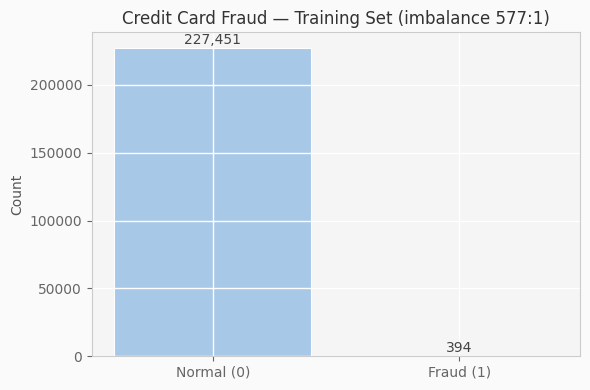

In [2]:
x_train, y_train, x_test, y_test = load_fraud('data/creditcard.csv')

n_fraud  = int((y_train == 1).sum())
n_normal = int((y_train == 0).sum())
print(f'Training set — Normal: {n_normal:,}  Fraud: {n_fraud:,}')
print(f'Imbalance ratio: {n_normal / n_fraud:.1f}:1')

plot_class_distribution(
    y_train,
    title=f'Credit Card Fraud — Training Set (imbalance {n_normal/n_fraud:.0f}:1)',
    save_path='outputs/plots/imbalance.png'
)

## 2. Train Vanilla GAN on minority class only

[Vanilla GAN] Epoch 50/300  D: 1.0149  G: 0.9628
[Vanilla GAN] Epoch 100/300  D: 1.1891  G: 0.8779
[Vanilla GAN] Epoch 150/300  D: 1.0888  G: 1.0604
[Vanilla GAN] Epoch 200/300  D: 1.0470  G: 0.9838
[Vanilla GAN] Epoch 250/300  D: 0.8437  G: 1.0762
[Vanilla GAN] Epoch 300/300  D: 1.0241  G: 1.0618
[Vanilla GAN] Model saved to outputs/vanilla_gan.pt


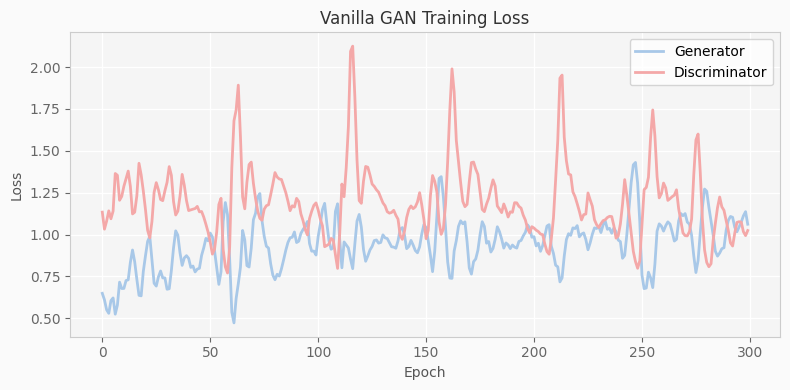

[Vanilla GAN] Loss curve saved to outputs/plots/vanilla_gan_loss.png


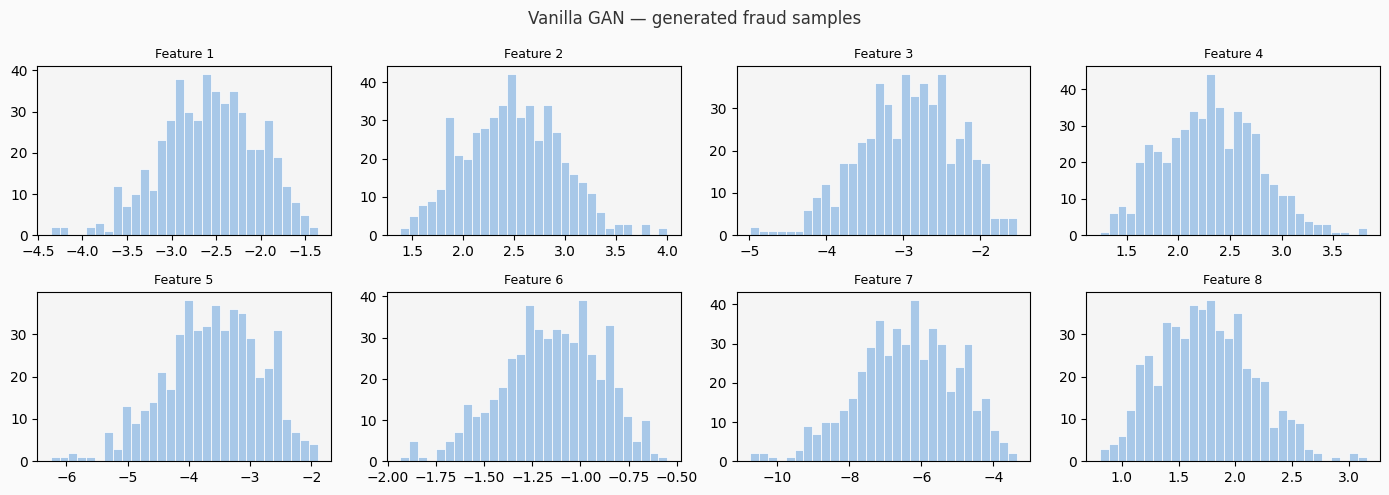

In [3]:
minority_loader = get_minority_loader(x_train, y_train, MINORITY_CLASS, batch_size=64)
G_vanilla, g_losses_v, d_losses_v = train_vanilla_gan(
    minority_loader, device, z_dim=Z_DIM, data_dim=DATA_DIM, epochs=GAN_EPOCHS,
    save_path='outputs/vanilla_gan.pt',
    plot_path='outputs/plots/vanilla_gan_loss.png'
)

samples_vanilla = gen_vanilla(G_vanilla, 500, Z_DIM, device)
plot_generated_samples(samples_vanilla, 'Vanilla GAN — generated fraud samples',
                       save_path='outputs/generated_samples/vanilla.png')

## 3. Train WGAN on minority class only

[WGAN] Epoch 50/300  W-dist: 0.1397  G: 0.0018
[WGAN] Epoch 100/300  W-dist: 0.0856  G: 0.0021
[WGAN] Epoch 150/300  W-dist: 0.0786  G: 0.0569
[WGAN] Epoch 200/300  W-dist: 0.0493  G: 0.0009
[WGAN] Epoch 250/300  W-dist: 0.0647  G: 0.0165
[WGAN] Epoch 300/300  W-dist: 0.0528  G: 0.0137
[WGAN] Model saved to outputs/wgan.pt


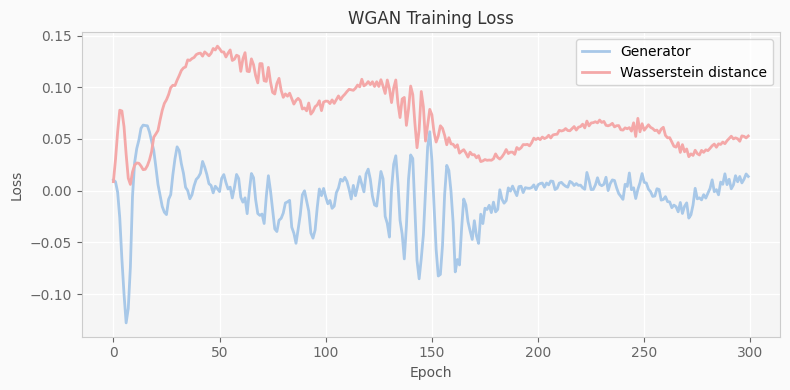

[WGAN] Loss curve saved to outputs/plots/wgan_loss.png


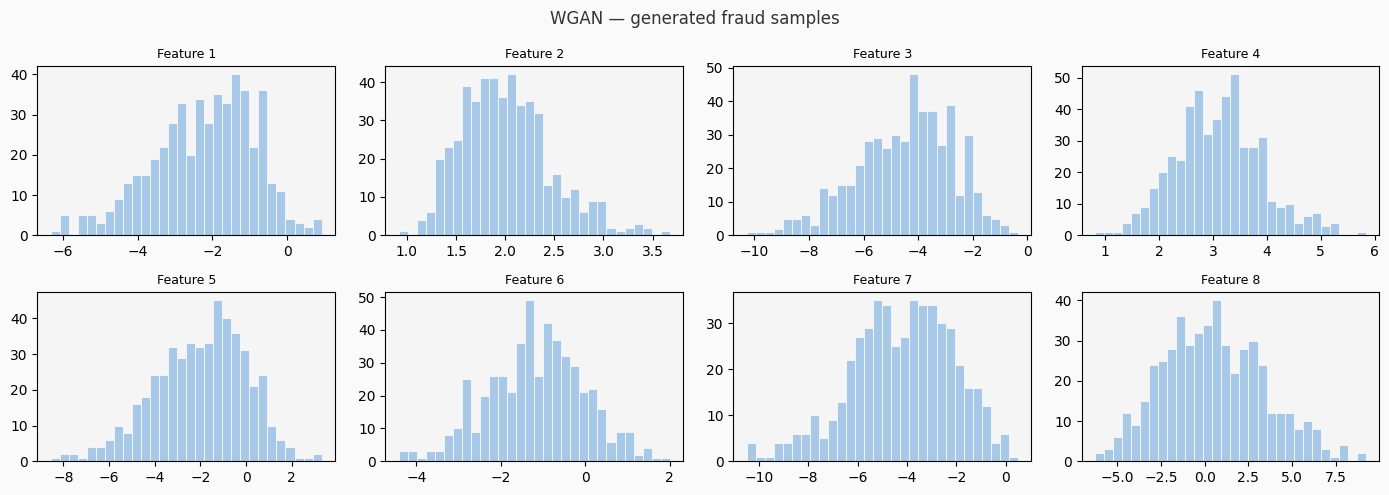

In [4]:
G_wgan, g_losses_w, c_losses_w = train_wgan(
    minority_loader, device, z_dim=Z_DIM, data_dim=DATA_DIM, epochs=GAN_EPOCHS,
    save_path='outputs/wgan.pt',
    plot_path='outputs/plots/wgan_loss.png'
)

samples_wgan = gen_wgan(G_wgan, 500, Z_DIM, device)
plot_generated_samples(samples_wgan, 'WGAN — generated fraud samples',
                       save_path='outputs/generated_samples/wgan.png')

## 4. Train CGAN on minority class only

[CGAN] Epoch 50/300  D: 1.3956  G: 0.7542
[CGAN] Epoch 100/300  D: 1.4324  G: 0.6308
[CGAN] Epoch 150/300  D: 2.2544  G: 0.4038
[CGAN] Epoch 200/300  D: 2.0626  G: 0.3446
[CGAN] Epoch 250/300  D: 1.6216  G: 0.6114
[CGAN] Epoch 300/300  D: 1.5266  G: 0.8240
[CGAN] Model saved to outputs/cgan.pt


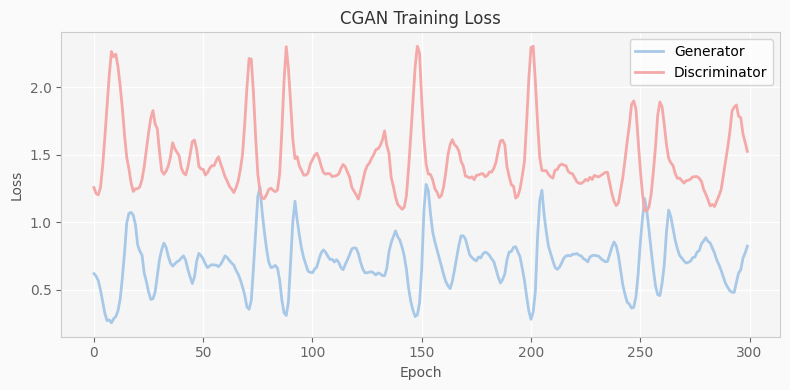

[CGAN] Loss curve saved to outputs/plots/cgan_loss.png


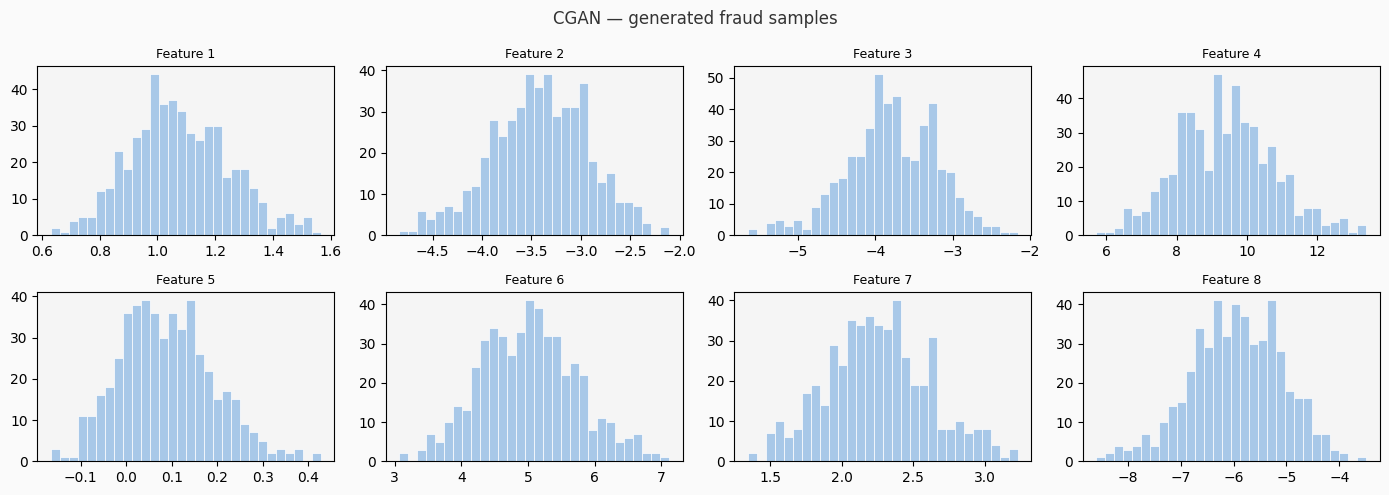

In [5]:
G_cgan, g_losses_c, d_losses_c = train_cgan(
    minority_loader, device, z_dim=Z_DIM, data_dim=DATA_DIM, epochs=GAN_EPOCHS,
    save_path='outputs/cgan.pt',
    plot_path='outputs/plots/cgan_loss.png'
)

samples_cgan = gen_cgan(G_cgan, 500, Z_DIM, MINORITY_CLASS, device)
plot_generated_samples(samples_cgan, 'CGAN — generated fraud samples',
                       save_path='outputs/generated_samples/cgan.png')

## 5. Build balanced datasets

In [6]:
n_needed = n_normal - n_fraud
print(f'Generating {n_needed:,} synthetic fraud samples per GAN')

# Vanilla-balanced
syn_v = gen_vanilla(G_vanilla, n_needed, Z_DIM, device)
syn_v_labels = torch.ones(n_needed, dtype=torch.long)
x_bal_v = torch.cat([x_train, syn_v])
y_bal_v = torch.cat([y_train, syn_v_labels])

# WGAN-balanced
syn_w = gen_wgan(G_wgan, n_needed, Z_DIM, device)
syn_w_labels = torch.ones(n_needed, dtype=torch.long)
x_bal_w = torch.cat([x_train, syn_w])
y_bal_w = torch.cat([y_train, syn_w_labels])

# CGAN-balanced
syn_c = gen_cgan(G_cgan, n_needed, Z_DIM, MINORITY_CLASS, device)
syn_c_labels = torch.ones(n_needed, dtype=torch.long)
x_bal_c = torch.cat([x_train, syn_c])
y_bal_c = torch.cat([y_train, syn_c_labels])

print(f'Balanced datasets: {len(y_bal_v):,} samples each')

Generating 227,057 synthetic fraud samples per GAN
Balanced datasets: 454,902 samples each


## 6. Train classifier on four scenarios

In [7]:
class MLP(nn.Module):
    def __init__(self, input_dim=29, num_classes=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64),  nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, num_classes),
        )
    def forward(self, x):
        return self.net(x)

def train_classifier(x, y, epochs=CLF_EPOCHS):
    model = MLP(DATA_DIM).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    crit = nn.CrossEntropyLoss()
    loader = get_classifier_loader(x, y, batch_size=256)
    model.train()
    for ep in range(epochs):
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward(); opt.step()
        print(f'  epoch {ep+1}/{epochs}  loss={loss.item():.4f}')
    return model

In [8]:
test_loader = get_classifier_loader(x_test, y_test, batch_size=512, shuffle=False)

print('--- Original (imbalanced) ---')
m_orig = train_classifier(x_train, y_train)
r_orig = evaluate_classifier(m_orig, test_loader, device, MINORITY_CLASS)

print('--- Balanced with Vanilla GAN ---')
m_v = train_classifier(x_bal_v, y_bal_v)
r_v = evaluate_classifier(m_v, test_loader, device, MINORITY_CLASS)

print('--- Balanced with WGAN ---')
m_w = train_classifier(x_bal_w, y_bal_w)
r_w = evaluate_classifier(m_w, test_loader, device, MINORITY_CLASS)

print('--- Balanced with CGAN ---')
m_c = train_classifier(x_bal_c, y_bal_c)
r_c = evaluate_classifier(m_c, test_loader, device, MINORITY_CLASS)

--- Original (imbalanced) ---
  epoch 1/10  loss=0.0001
  epoch 2/10  loss=0.0000
  epoch 3/10  loss=0.0000
  epoch 4/10  loss=0.0000
  epoch 5/10  loss=0.0070
  epoch 6/10  loss=0.0000
  epoch 7/10  loss=0.0000
  epoch 8/10  loss=0.0000
  epoch 9/10  loss=0.0001
  epoch 10/10  loss=0.0008
--- Balanced with Vanilla GAN ---
  epoch 1/10  loss=0.0003
  epoch 2/10  loss=0.0005
  epoch 3/10  loss=0.0001
  epoch 4/10  loss=0.0001
  epoch 5/10  loss=0.0002
  epoch 6/10  loss=0.0010
  epoch 7/10  loss=0.0004
  epoch 8/10  loss=0.0002
  epoch 9/10  loss=0.0002
  epoch 10/10  loss=0.0010
--- Balanced with WGAN ---
  epoch 1/10  loss=0.0161
  epoch 2/10  loss=0.0005
  epoch 3/10  loss=0.0002
  epoch 4/10  loss=0.0003
  epoch 5/10  loss=0.0001
  epoch 6/10  loss=0.0004
  epoch 7/10  loss=0.0032
  epoch 8/10  loss=0.0001
  epoch 9/10  loss=0.0001
  epoch 10/10  loss=0.0001
--- Balanced with CGAN ---
  epoch 1/10  loss=0.0004
  epoch 2/10  loss=0.0018
  epoch 3/10  loss=0.0011
  epoch 4/10  loss=0.

## 7. Compare results

Scenario            Acc   Prec  Recall     F1    AUC
-------------------------------------------------------
Original         0.9994 0.7905 0.8469 0.8177 0.9790
Vanilla GAN      0.9994 0.8316 0.8061 0.8187 0.9773
WGAN             0.9994 0.8889 0.7347 0.8045 0.9784
CGAN             0.9995 0.8851 0.7857 0.8324 0.9782


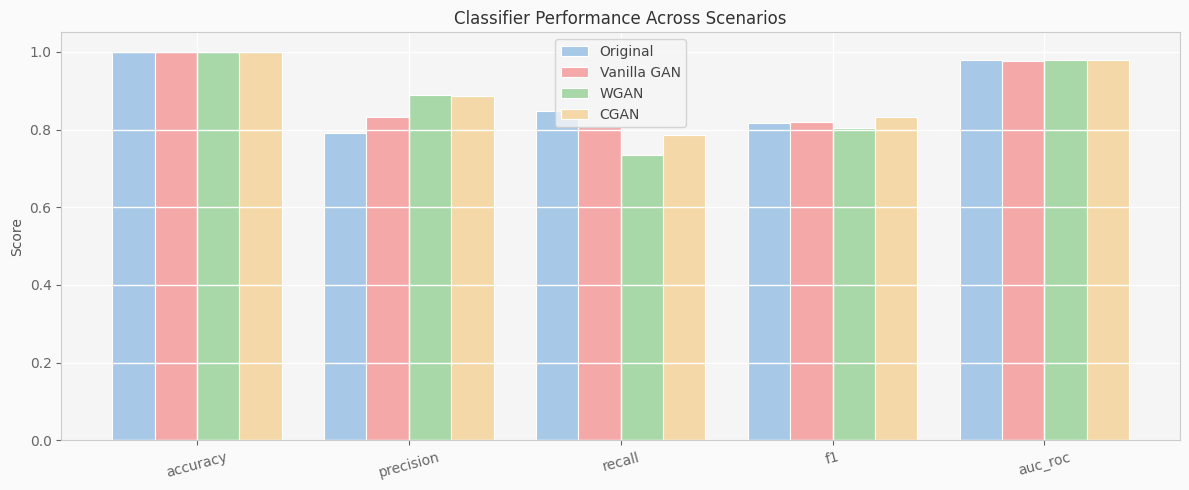

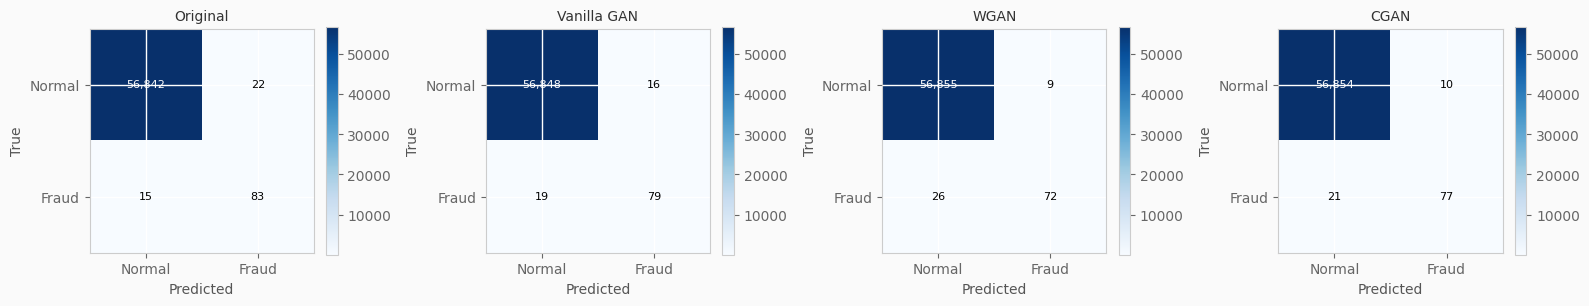

In [9]:
results = {'Original': r_orig, 'Vanilla GAN': r_v, 'WGAN': r_w, 'CGAN': r_c}

print(f'{"Scenario":<16} {"Acc":>6} {"Prec":>6} {"Recall":>7} {"F1":>6} {"AUC":>6}')
print('-' * 55)
for name, r in results.items():
    print(f'{name:<16} '
          f'{r["accuracy"]:.4f} '
          f'{r["precision"]:.4f} '
          f'{r["recall"]:.4f} '
          f'{r["f1"]:.4f} '
          f'{r["auc_roc"]:.4f}')

plot_metric_comparison(results, save_path='outputs/plots/metrics.png')
plot_confusion_matrices(results, save_path='outputs/plots/confusion.png')

## 8. Conclusion

With the Credit Card Fraud dataset:
- **Original**: high accuracy but poor recall on fraud — classifier mostly predicts 'normal'
- **Vanilla GAN**: synthetic fraud samples improve recall and F1
- **WGAN**: more stable training, typically higher sample quality than Vanilla GAN
- **CGAN**: label-conditioned generation produces the most targeted fraud samples

Key metrics: `recall` and `f1` on the fraud class — these matter most in real fraud detection.